<a href="https://colab.research.google.com/github/JuanRojasFarias/Herramienta.ciencias.datos/blob/main/tarea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#@title 1) Importar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# Fijar semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("✅ Librerías importadas correctamente.")


✅ Librerías importadas correctamente.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
→ x_train: (60000, 28, 28), y_train: (60000,)
→ x_test : (10000, 28, 28), y_test : (10000,)


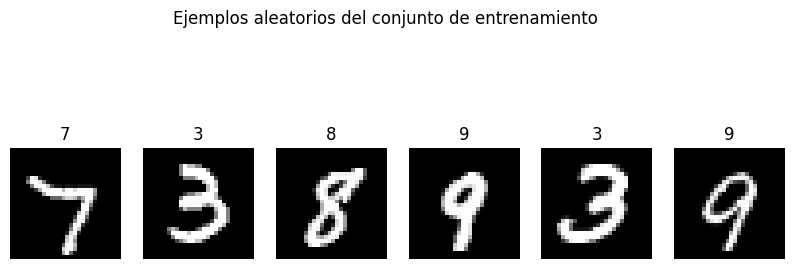

<ipython-input-3-4fd077aacd53>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y_train, palette="tab10")


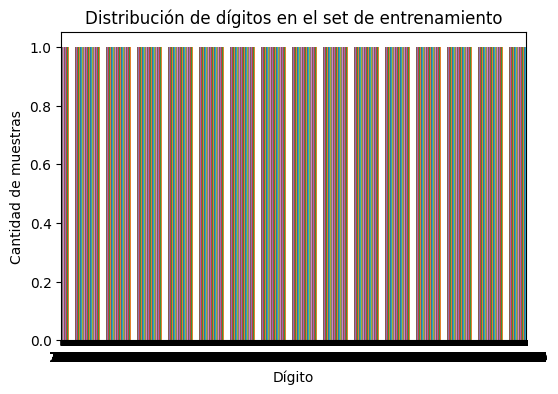

In [3]:
#@title 2) Cargar dataset MNIST desde Keras
from tensorflow.keras.datasets import mnist

# Descarga automática de MNIST (si ya está en caché, se usa local)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"→ x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"→ x_test : {x_test.shape}, y_test : {y_test.shape}")

# Mostrar 6 ejemplos aleatorios de dígitos en entrenamiento
plt.figure(figsize=(10, 4))
for i, idx in enumerate(np.random.choice(len(x_train), size=6, replace=False)):
    plt.subplot(1, 6, i+1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(int(y_train[idx]))
    plt.axis("off")
plt.suptitle("Ejemplos aleatorios del conjunto de entrenamiento")
plt.show()

# Distribución de clases en entrenamiento
plt.figure(figsize=(6,4))
sns.countplot(y_train, palette="tab10")
plt.title("Distribución de dígitos en el set de entrenamiento")
plt.xlabel("Dígito")
plt.ylabel("Cantidad de muestras")
plt.show()


In [4]:
#@title 3) Normalizar y reorganizar dimensiones
# Convertir a float32 y escalar píxeles a [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Actualmente tienen forma (num_ejemplos, 28,28).
# Agregamos dimensión de canal al final: (28,28,1)
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

print("→ Formato final x_train:", x_train.shape)
print("→ Formato final x_test :", x_test.shape)

# Convertir etiquetas a one-hot (categorical)
num_classes = 10
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)
print("→ Formato y_train one-hot:", y_train_cat.shape)


→ Formato final x_train: (60000, 28, 28, 1)
→ Formato final x_test : (10000, 28, 28, 1)
→ Formato y_train one-hot: (60000, 10)


In [5]:
#@title 4) Construir un modelo CNN básico
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#@title 5) Entrenar el modelo (10 épocas)
EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    x_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,  # 10% del train como validación
    verbose=2
)


Epoch 1/10
422/422 - 49s - 116ms/step - accuracy: 0.9171 - loss: 0.2726 - val_accuracy: 0.9820 - val_loss: 0.0596
Epoch 2/10
422/422 - 41s - 96ms/step - accuracy: 0.9752 - loss: 0.0799 - val_accuracy: 0.9868 - val_loss: 0.0430
Epoch 3/10
422/422 - 41s - 97ms/step - accuracy: 0.9828 - loss: 0.0577 - val_accuracy: 0.9910 - val_loss: 0.0359
Epoch 4/10
422/422 - 42s - 99ms/step - accuracy: 0.9869 - loss: 0.0433 - val_accuracy: 0.9910 - val_loss: 0.0332
Epoch 5/10
422/422 - 82s - 195ms/step - accuracy: 0.9888 - loss: 0.0366 - val_accuracy: 0.9900 - val_loss: 0.0341
Epoch 6/10
422/422 - 41s - 96ms/step - accuracy: 0.9897 - loss: 0.0319 - val_accuracy: 0.9913 - val_loss: 0.0323
Epoch 7/10
422/422 - 41s - 97ms/step - accuracy: 0.9917 - loss: 0.0251 - val_accuracy: 0.9920 - val_loss: 0.0309
Epoch 8/10
422/422 - 42s - 100ms/step - accuracy: 0.9927 - loss: 0.0230 - val_accuracy: 0.9927 - val_loss: 0.0340
Epoch 9/10
422/422 - 41s - 98ms/step - accuracy: 0.9936 - loss: 0.0191 - val_accuracy: 0.9917

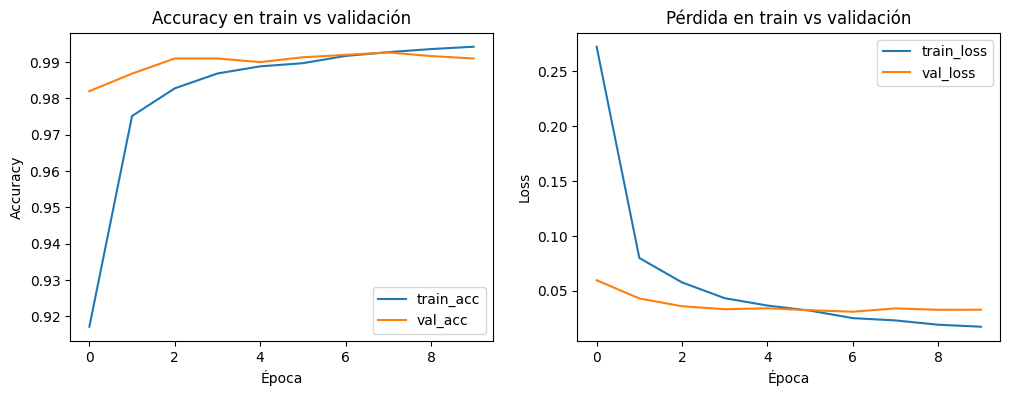

➡ Test Loss    : 0.0247
➡ Test Accuracy: 0.9923
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



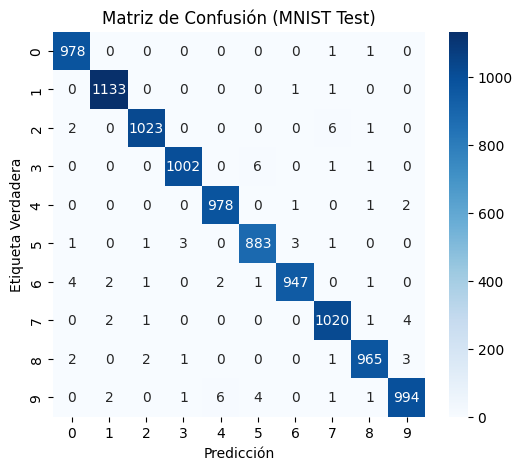

In [7]:
#@title 6) Plot de loss/accuracy y evaluar en test set
# 6.1) Curvas de accuracy y pérdida
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy en train vs validación")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.title("Pérdida en train vs validación")

plt.show()

# 6.2) Evaluar en test
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"➡ Test Loss    : {test_loss:.4f}")
print(f"➡ Test Accuracy: {test_acc:.4f}")

# 6.3) Reporte de clasificación (predicciones en test)
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred))

# 6.4) Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Verdadera")
plt.title("Matriz de Confusión (MNIST Test)")
plt.show()


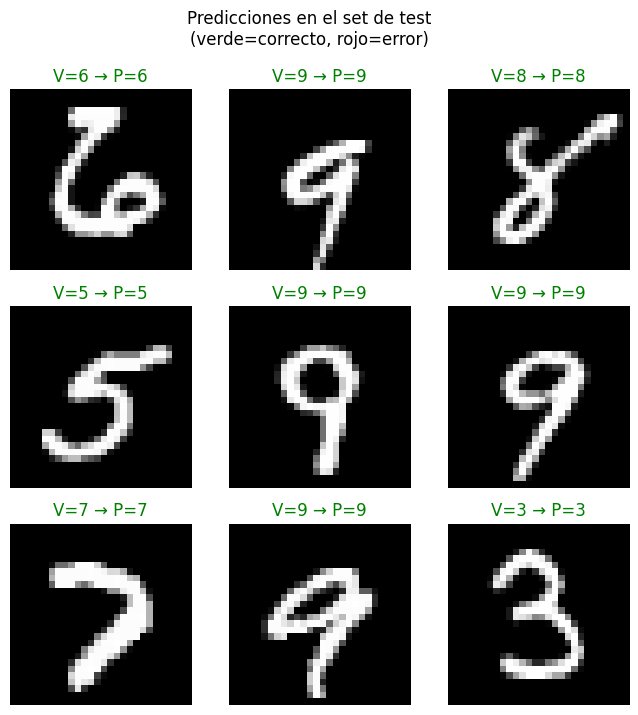

In [8]:
#@title 7) Ver algunas predicciones correctas y errores
# Elegir 9 imágenes aleatorias del test set
indices = np.random.choice(len(x_test), size=9, replace=False)

plt.figure(figsize=(8,8))
for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)
    img = x_test[idx].squeeze()  # 28×28
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    pred = y_pred[idx]
    true = y_test[idx]
    color = "green" if pred == true else "red"
    plt.title(f"V={true} → P={pred}", color=color)
plt.suptitle("Predicciones en el set de test\n(verde=correcto, rojo=error)")
plt.show()
